In [1]:
import nltk
print(nltk.__version__)

3.10.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
email=pd.read_csv('mail_data.csv')
email.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


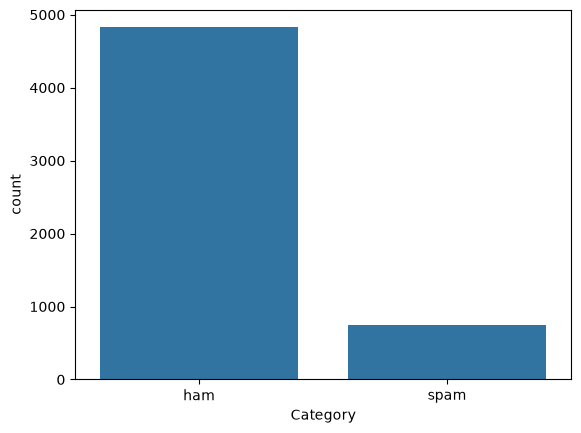

In [7]:
unbalanced=sns.countplot(x='Category',data=email)
plt.savefig('unbalanced_data',dpi=300)

In [8]:
ham_msg=email[email['Category']== 'ham']
spam_msg=email[email['Category']=='spam']
ham_msgb=ham_msg.sample(n=len(spam_msg),random_state=30)
email_bal=pd.concat([ham_msgb,spam_msg]).reset_index(drop=True)
email_bal.head(5)
#sns.countplot(x='Category',data=email_bal)

,Category,Message
0,ham,Can you pls send me that company name. In saib...
1,ham,Pls go there today &lt;#&gt; . I dont want an...
2,ham,Armand says get your ass over to epsilon
3,ham,Am on the uworld site. Am i buying the qbank o...
4,ham,I'm e person who's doing e sms survey...


In [6]:
punc_list= string.punctuation
def remove_punc(st):
    func=str.maketrans("","",punc_list)
    return st.translate(func)

email_bal['Message']=email_bal['Message'].apply(lambda x:remove_punc(x))
email_bal.head(5)



,Category,Message
0,ham,Can you pls send me that company name In saiba...
1,ham,Pls go there today ltgt I dont want any excuses
2,ham,Armand says get your ass over to epsilon
3,ham,Am on the uworld site Am i buying the qbank on...
4,ham,Im e person whos doing e sms survey


In [7]:
def remove_stpw(st):
    stwp=stopwords.words('english')
    colword=[]
    for word in str(st).split():
        word=word.lower()
        if word not in stwp:
            colword.append(word)

    output=" ".join(colword)
    return output

email_bal['Message']=email_bal['Message'].apply(lambda x: remove_stpw(x))
email_bal.head(5)


,Category,Message
0,ham,pls send company name saibaba colany
1,ham,pls go today ltgt dont want excuses
2,ham,armand says get ass epsilon
3,ham,uworld site buying qbank buying self assessmen...
4,ham,im e person whos e sms survey


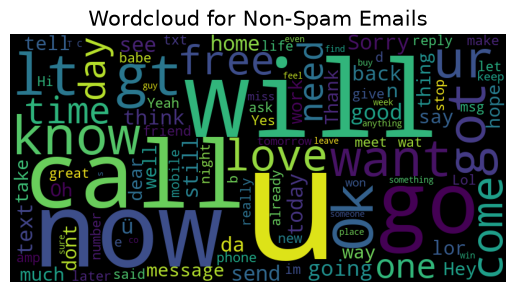

In [10]:
def plot_wc(dat,ty):
    email_c=" ".join(email['Message'])
    wc=WordCloud(background_color='black',max_words=100,height=400,width=800).generate(email_c)
    #plt.figure(figsize=(7,7))
    plt.imshow(wc)#,interpolation='bilinear')
    plt.title(f'Wordcloud for {ty} Emails',fontsize=15)
    plt.axis('off')
    plt.show

plot_wc(email_bal[email_bal['Category']=='ham'],'Non-Spam')
#plot_wc(email_bal[email_bal['Category']=='spam'],'Spam')
plt.savefig('non-spam',dpi=300)

                     

In [12]:
train_X,test_X,train_Y,test_Y=train_test_split(email_bal['Message'],email_bal['Category'],test_size=0.2,random_state=30)
tokenizer=Tokenizer(num_words=2000)
tokenizer.fit_on_texts(train_X)
train_sequence=tokenizer.texts_to_sequences(train_X)
test_sequence=tokenizer.texts_to_sequences(test_X)

train_sequence=pad_sequences(train_sequence,maxlen=100,padding='post',truncating='post')
test_sequence=pad_sequences(test_sequence,maxlen=100,padding='post',truncating='post')

train_Y=(train_Y=='spam').astype(int)
test_Y=(test_Y=='spam').astype(int)

print("Vocabulary size:", len(tokenizer.word_index))
print("Maximum word index:", max(tokenizer.word_index.values()))

print("Maximum train index:", train_sequence.max())
print("Maximum test index:", test_sequence.max())
print(train_Y.unique())
print(train_Y.value_counts())

print(model.loss)

pred = model.predict(test_sequence[:10])
print(pred)
print(train_sequence.shape)
print(train_sequence[:3])
model.summary()
print(history.history['accuracy'])
print(history.history['loss'])
small_X = train_sequence[:100]
small_Y = train_Y[:100]

history = model.fit(
    small_X,
    small_Y,
    epochs=20,
    batch_size=16
)

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Embedding(len(tokenizer.word_index)+1, 16),
    tf.keras.layers.
    
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    small_X,
    small_Y,
    epochs=20,
    batch_size=16
)

print(train_X.iloc[0])
print(train_X.iloc[1])
print(train_X.iloc[2])
print(np.unique(small_Y, return_counts=True))
print(small_Y[:30])
print(train_sequence.shape)
print(train_Y.shape)

In [10]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Embedding(len(tokenizer.word_index)+1,16),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

small_X = train_sequence[:100]
small_Y = train_Y[:100]

history = model.fit(
    train_sequence,
    train_Y,
    validation_data=(test_sequence,test_Y),
    epochs=32,
    batch_size=32
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 16)             │          64,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 16)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 64,977 (253.82 KB)

 Trainable params: 64,977 (253.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4879 - loss: 0.6929 - val_accuracy: 0.5151 - val_loss: 0.6884
Epoch 2/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4979 - loss: 0.6886 - val_accuracy: 0.5151 - val_loss: 0.6849
Epoch 3/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4996 - loss: 0.6833 - val_accuracy: 0.6823 - val_loss: 0.6805
Epoch 4/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5967 - loss: 0.6759 - val_accuracy: 0.7659 - val_loss: 0.6706
Epoch 5/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7013 - loss: 0.6631 - val_accuracy: 0.5485 - val_loss: 0.6537
Epoch 6/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7607 - loss: 0.6416 - val_accuracy: 0.8930 - val_loss: 0.6297
Epoch 7/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8326 - loss: 0.6051 - val_accuracy: 0.9398 - val_loss: 0.5981
Epoch 8/32
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8887 - loss: 0.5592 - val_accuracy: 0.8395 - val_loss

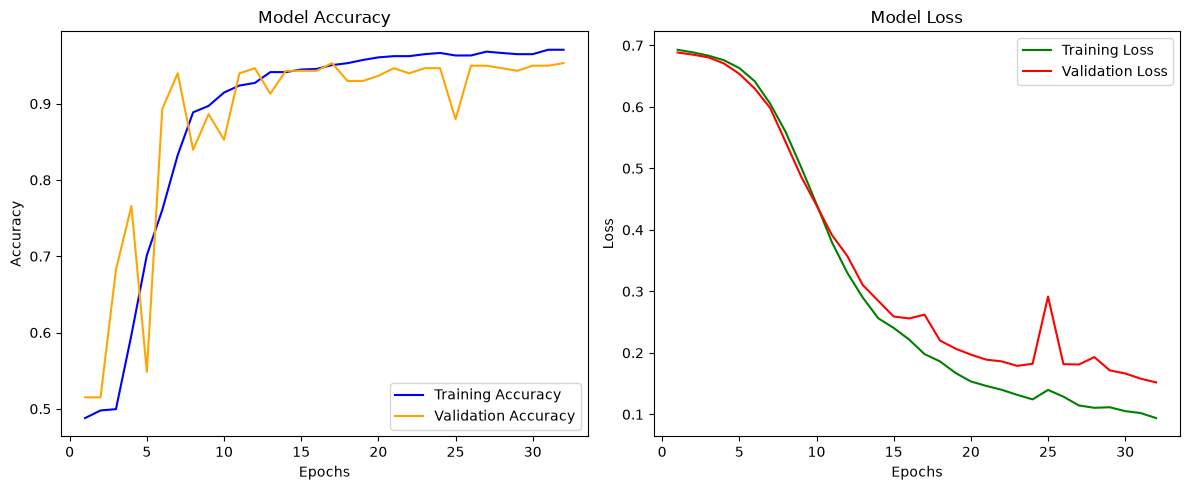

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib.pyplot as plt

# Example data from your log
epochs = list(range(1, 33))
train_acc = [0.4879, 0.4979, 0.4996, 0.5967, 0.7013, 0.7607, 0.8326, 0.8887, 0.8971, 0.9146, 0.9238, 0.9272, 0.9414, 0.9414, 0.9448, 0.9456, 0.9506, 0.9531, 0.9573, 0.9607, 0.9623, 0.9623, 0.9649, 0.9665, 0.9632, 0.9632, 0.9682, 0.9665, 0.9649, 0.9649, 0.9707, 0.9707]
val_acc = [0.5151, 0.5151, 0.6823, 0.7659, 0.5485, 0.8930, 0.9398, 0.8395, 0.8863, 0.8528, 0.9398, 0.9465, 0.9130, 0.9431, 0.9431, 0.9431, 0.9532, 0.9298, 0.9298, 0.9365, 0.9465, 0.9398, 0.9465, 0.9465, 0.8796, 0.9498, 0.9498, 0.9465, 0.9431, 0.9498, 0.9498, 0.9532]
train_loss = [0.6929, 0.6886, 0.6833, 0.6759, 0.6631, 0.6416, 0.6051, 0.5592, 0.5021, 0.4420, 0.3798, 0.3300, 0.2898, 0.2562, 0.2405, 0.2216, 0.1979, 0.1861, 0.1674, 0.1535, 0.1462, 0.1399, 0.1317, 0.1243, 0.1397, 0.1287, 0.1144, 0.1106, 0.1115, 0.1052, 0.1021, 0.0939]
val_loss = [0.6884, 0.6849, 0.6805, 0.6706, 0.6537, 0.6297, 0.5981, 0.5428, 0.4870, 0.4399, 0.3916, 0.3573, 0.3102, 0.2846, 0.2591, 0.2559, 0.2621, 0.2200, 0.2069, 0.1971, 0.1889, 0.1861, 0.1788, 0.1822, 0.2915, 0.1816, 0.1810, 0.1931, 0.1715, 0.1664, 0.1580, 0.1519]

# Plot accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, label='Training Accuracy', color='blue')
plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(epochs, train_loss, label='Training Loss', color='green')
plt.plot(epochs, val_loss, label='Validation Loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

plt.savefig('Tensorflow work chart',dpi=300)

In [11]:
print(tf.__version__)
print(tf.keras.__version__)
pred = model.predict(test_sequence[:20])

print(pred.flatten())
print(history.history['accuracy'])
#print(history.history['val_accuracy'])
pred = (model.predict(small_X) > 0.5).astype(int)

print(np.unique(pred, return_counts=True))
print(email_bal['Category'].value_counts())
pred = model.predict(small_X[:20])
print(pred.flatten())
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

vectorizer = TfidfVectorizer(max_features=2000)

X_train = vectorizer.fit_transform(train_X)
X_test = vectorizer.transform(test_X)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, train_Y)

pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(test_Y, pred))

2.21.0
3.15.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
[0.02525811 0.96603197 0.89134306 0.02896166 0.05224998 0.01945839
 0.01875759 0.9914836  0.14000131 0.9641417  0.99697983 0.1175134
 0.9988486  0.998512   0.69086623 0.02865373 0.9978374  0.95597994
 0.19888075 0.9207713 ]
[0.4878661036491394, 0.49790793657302856, 0.49958157539367676, 0.5966527462005615, 0.701255202293396, 0.760669469833374, 0.8326359987258911, 0.888702929019928, 0.897071123123169, 0.9146443605422974, 0.92384934425354, 0.9271966814994812, 0.9414225816726685, 0.9414225816726685, 0.9447698593139648, 0.9456067085266113, 0.9506276249885559, 0.9531380534172058, 0.9573221802711487, 0.9606694579124451, 0.9623430967330933, 0.9623430967330933, 0.9648535847663879, 0.9665272235870361, 0.9631799459457397, 0.9631799459457397, 0.9682008624076843, 0.9665272235870361, 0.9648535847663879, 0.9648535847663879, 0.9707112908363342, 0.9707112908363342]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
(array([0, 1]), array([44, 56]))
Category
ham   

#es=EarlyStopping(patience=3,monitor='val_accuracy',restore_best_weights=True)
#ir=ReduceLROnPlateau(patience=2,monitor='val_loss',factor=0.5,verbose=0)
history= model.fit(
    train_sequence,train_Y,
    validation_data=(test_sequence,test_Y),
    epochs=40,
    batch_size=32,
    callbacks=[ir,es]
)


test_loss,test_accuracy=model.evaluate(test_sequence,test_Y)
print(test_loss)
print(test_accuracy)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
scaler=StandardScaler()
lr=LogisticRegression()
lrx=scaler.fit_transform(train_sequence)
lr.fit(lrx,train_Y)
print('Training Accuracy:',metrics.roc_auc_score(train_Y,lr.predict_proba(lrx)[:,1]))
print('Validation Accuracy:',metrics.roc_auc_score(test_Y,lr.predict_proba(test_sequence)[:,1]))
from sklearn.metrics import classification_report

pred = lr.predict(test_sequence)

print(classification_report(test_Y, pred))
#pred = model.predict(test_sequence)

#print(classification_report(test_Y, pred))

Training Accuracy: 0.8587479621049564
Validation Accuracy: 0.7862516793551276
              precision    recall  f1-score   support

           0       0.81      0.69      0.74       154
           1       0.71      0.83      0.77       145

    accuracy                           0.76       299
   macro avg       0.76      0.76      0.76       299
weighted avg       0.76      0.76      0.75       299

